<a href="https://colab.research.google.com/github/cpapad06/DSC511_PROJECT/blob/main/BigData_weather_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics — Semester Project
## Weather Pattern Analysis with Open Meteo API
**Phases covered:** Phase 0 — Data Acquisition · Phase 1 — Exploratory Data Analysis · Phase 2A — Machine Learning with Spark MLlib

---
**Dataset:** Open Meteo Historical Weather API  
**Time range:** 2019–2025 (5 years, hourly resolution)  
**Cities:** 12 global cities across diverse climate zones  
**Tech stack:** Python · Apache Spark · Spark MLlib · Pandas · Matplotlib · Seaborn


# DSC511_PROJECT - Weather Analysis for 12 cities (2019-2025)

# Project Overview
This project builds an end-to-end big-data pipeline on seven years of hourly weather data (2019–2025) for twelve globally distributed cities, sourced from the Open-Meteo API. The 736,416-row dataset flows through four phases:
-  ingestion
-  exploratory analysis with Apache Spark
-  machine learning with Spark MLlib (a GBT regressor predicting next-hour temperature at R² = 0.884)
-  climate-similarity analysis combining KMeans clustering with GraphFrames and NetworkX.
These techniques were used to cover multiple concepts taught throughout the course.

# Dataset

The dataset comes from the **Open-Meteo Historical Weather Archive API**, a free reanalysis-based service providing hourly weather data with global coverage. We collected seven years of observations (**2019-01-01 → 2025-12-31**) for **twelve cities** spanning diverse climate zones — Mediterranean (Athens, Nicosia), Desert (Cairo), Continental (Moscow, Berlin), Oceanic (London, Sydney), Humid Subtropical (New York, Tokyo), Tropical (Mumbai, São Paulo), and Tropical Highland (Nairobi). Each city contributes exactly **61,368 hourly rows**, yielding a master dataset of **736,416 rows × 27 columns** (≈ 290 MB in memory, 9.1 MB compressed as Snappy Parquet) with **zero missing values** after ingestion.

### Variables

Ten hourly weather variables were fetched per city:
- **`temperature_2m`** (air temperature 2 m above ground, °C)
- **`apparent_temperature`** (perceived temperature accounting for humidity and wind, °C)
- **`relative_humidity_2m`** (%)
- **`precipitation`** (mm/hr)
- **`wind_speed_10m`** (km/h)
- **`wind_direction_10m`** (degrees)
- **`surface_pressure`** (hPa)
- **`cloud_cover`** (%)
- **`shortwave_radiation`** (incoming solar, W/m²)
- **`et0_fao_evapotranspiration`** (FAO Penman–Monteith reference evapotranspiration, mm/hr)
-  metadata (city, latitude, longitude, climate label) and time features (year, month, day, hour, day-of-week, day-of-year, hemisphere-aware season, plus sine/cosine cyclical encodings of hour and month for ML).

---
# Phase 0 — Data Acquisition
## 0.1 Imports & Configuration

We define all cities, variables, and date ranges here. All configuration is in one place so it is easy to extend (add cities, extend the time range, add variables).


In [ ]:
import os
import time
import requests
import warnings
import pandas as pd
import numpy as np
from pathlib import Path

warnings.filterwarnings("ignore")

# ── City list: 12 cities across diverse climate zones  Select this cities because they came from differente climates and areas across earth
CITIES = [
    {"name": "Nicosia",   "lat": 35.17,  "lon":  33.36,  "timezone": "Asia/Nicosia",           "climate": "Mediterranean"},
    {"name": "Athens",    "lat": 37.98,  "lon":  23.73,  "timezone": "Europe/Athens",           "climate": "Mediterranean"},
    {"name": "London",    "lat": 51.51,  "lon":  -0.13,  "timezone": "Europe/London",           "climate": "Oceanic"},
    {"name": "Berlin",    "lat": 52.52,  "lon":  13.41,  "timezone": "Europe/Berlin",           "climate": "Continental"},
    {"name": "Moscow",    "lat": 55.75,  "lon":  37.62,  "timezone": "Europe/Moscow",           "climate": "Continental"},
    {"name": "Cairo",     "lat": 30.06,  "lon":  31.25,  "timezone": "Africa/Cairo",            "climate": "Desert"},
    {"name": "Mumbai",    "lat": 19.08,  "lon":  72.88,  "timezone": "Asia/Kolkata",            "climate": "Tropical"},
    {"name": "Tokyo",     "lat": 35.68,  "lon": 139.69,  "timezone": "Asia/Tokyo",              "climate": "Humid Subtropical"},
    {"name": "New_York",  "lat": 40.71,  "lon": -74.01,  "timezone": "America/New_York",        "climate": "Humid Subtropical"},
    {"name": "Sao_Paulo", "lat": -23.55, "lon": -46.63,  "timezone": "America/Sao_Paulo",       "climate": "Tropical"},
    {"name": "Sydney",    "lat": -33.87, "lon": 151.21,  "timezone": "Australia/Sydney",        "climate": "Oceanic"},
    {"name": "Nairobi",   "lat":  -1.29, "lon":  36.82,  "timezone": "Africa/Nairobi",          "climate": "Tropical Highland"},
]

# ── Weather variables to fetch
HOURLY_VARS = [
    "temperature_2m", # Air temperature measured at 2
    "apparent_temperature", # The "feels-like" temperature
    "relative_humidity_2m", # The percentage of moisture in the air at 2 meters
    "precipitation", # Total liquid-equivalent precipitation (rain, snow, etc.) accumulated over the hour, usually in millimeters.
    "wind_speed_10m", # Wind speed measured at 10 meters above the ground
    "wind_direction_10m", # Wind direction (in degrees) measured at 10 meters above the ground
    "surface_pressure", # Atmospheric pressure at the actual ground surface elevation
    "cloud_cover", # The percentage of the sky covered by clouds.
    "shortwave_radiation", #  Incoming solar radiation reaching the surface, measured in watts per square meter (W/m²)
    "et0_fao_evapotranspiration", # Reference evapotranspiration computed via the FAO Penman-Monteith equation, estimating water loss from a standard grass surface
]

START_DATE = "2019-01-01"
END_DATE   = "2025-12-31"

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Cities     : {len(CITIES)}")
print(f"Variables  : {len(HOURLY_VARS)}")
print(f"Date range : {START_DATE} → {END_DATE}")
print(f"Est. rows  : ~{len(CITIES) * 5 * 8760:,} (12 cities × 5 years × 8760 hrs)")

Cities     : 12
Variables  : 10
Date range : 2019-01-01 → 2025-12-31
Est. rows  : ~525,600 (12 cities × 5 years × 8760 hrs)


## 0.2 Fetching Function

The function calls the Open Meteo `/v1/archive` endpoint for one city and returns a tidy Pandas DataFrame.  
It adds derived time columns (year, month, hour, season, hemisphere-aware) which will be used across all later phases.


In [ ]:
BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

def fetch_city(city: dict, start: str, end: str, retries: int = 3) -> pd.DataFrame:
    """
    Fetch historical hourly weather data for one city from Open Meteo API.
    Returns a tidy Pandas DataFrame with metadata and time-feature columns added.
    """
    params = {
        "latitude":   city["lat"],
        "longitude":  city["lon"],
        "start_date": start,
        "end_date":   end,
        "hourly":     ",".join(HOURLY_VARS),
        "timezone":   city["timezone"],
    }

    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(BASE_URL, params=params, timeout=90)
            resp.raise_for_status()
            break
        except Exception as e:
            if attempt == retries:
                raise
            print(f"    Retry {attempt}/{retries} for {city['name']}: {e}")
            time.sleep(2 ** attempt)

    data = resp.json()
    df = pd.DataFrame(data["hourly"])
    df.rename(columns={"time": "timestamp"}, inplace=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # ── Metadata columns ────────────────────────────────────────────────────────
    df["city"]      = city["name"]
    df["latitude"]  = city["lat"]
    df["longitude"] = city["lon"]
    df["timezone"]  = city["timezone"]
    df["climate"]   = city["climate"]

    # ── Time features ───────────────────────────────────────────────────────────
    df["year"]      = df["timestamp"].dt.year
    df["month"]     = df["timestamp"].dt.month
    df["day"]       = df["timestamp"].dt.day
    df["hour"]      = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["dayofyear"] = df["timestamp"].dt.dayofyear

    # Hemisphere-aware season
    is_southern = city["lat"] < 0
    def get_season(m, southern):
        if m in [12, 1, 2]:   return "Summer" if southern else "Winter"
        if m in [3, 4, 5]:    return "Autumn" if southern else "Spring"
        if m in [6, 7, 8]:    return "Winter" if southern else "Summer"
        return "Spring" if southern else "Autumn"
    df["season"] = df["month"].apply(lambda m: get_season(m, is_southern))

    # Cyclical encoding for hour and month (useful for ML)
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]  / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]  / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

print("fetch_city() function defined.")

fetch_city() function defined.


## 0.3 Main Ingestion Loop

Iterates over all cities, fetches data, saves individual Parquet files per city, and assembles the master dataset.


In [ ]:
all_dfs = []
failed  = []

print(f"Starting ingestion for {len(CITIES)} cities...\n")

for i, city in enumerate(CITIES, 1):
    city_file = DATA_DIR / f"{city['name'].lower()}.parquet"

    # Skip if already downloaded (re-run safe)
    if city_file.exists():
        df = pd.read_parquet(city_file)
        print(f"  [{i:02d}/{len(CITIES)}] {city['name']:12s} — loaded from cache ({len(df):,} rows)")
        all_dfs.append(df)
        continue

    try:
        df = fetch_city(city, START_DATE, END_DATE)
        df.to_parquet(city_file, index=False, engine="pyarrow", compression="snappy")
        all_dfs.append(df)
        print(f"  [{i:02d}/{len(CITIES)}] {city['name']:12s} — fetched & saved ({len(df):,} rows)")
        time.sleep(0.6)  # polite rate limiting

    except Exception as e:
        print(f"  [{i:02d}/{len(CITIES)}] {city['name']:12s} — FAILED: {e}")
        failed.append(city["name"])

print(f"\nIngestion complete: {len(all_dfs)}/{len(CITIES)} cities OK", end="")
print(f" | Failed: {failed}" if failed else " | No failures")

Starting ingestion for 12 cities...

  [01/12] Nicosia      — fetched & saved (61,368 rows)
  [02/12] Athens       — fetched & saved (61,368 rows)
  [03/12] London       — fetched & saved (61,368 rows)
  [04/12] Berlin       — fetched & saved (61,368 rows)
    Retry 1/3 for Moscow: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=55.75&longitude=37.62&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_pressure%2Ccloud_cover%2Cshortwave_radiation%2Cet0_fao_evapotranspiration&timezone=Europe%2FMoscow
    Retry 2/3 for Moscow: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=55.75&longitude=37.62&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_

In [ ]:
import random

RETRY_CITIES = [c for c in CITIES if c["name"] in failed]
print(f"Retrying {len(RETRY_CITIES)} cities with backoff: {[c['name'] for c in RETRY_CITIES]}\n")

for i, city in enumerate(RETRY_CITIES):
    city_file = DATA_DIR / f"{city['name'].lower()}.parquet"

    for attempt in range(1, 7):
        wait = (2 ** attempt) + random.uniform(2, 6)
        print(f"  [{city['name']}] Attempt {attempt}/6 — waiting {wait:.1f}s first...")
        time.sleep(wait)

        try:
            df = fetch_city(city, START_DATE, END_DATE)
            df.to_parquet(city_file, index=False, engine="pyarrow", compression="snappy")
            all_dfs.append(df)
            failed.remove(city["name"])
            print(f"  [{city['name']}] ✓ Success — {len(df):,} rows saved")
            break

        except Exception as e:
            print(f"  [{city['name']}] ✗ Attempt {attempt} failed: {e}")
            if attempt == 6:
                print(f"  [{city['name']}] Giving up after 6 attempts.")

    # Long pause between cities
    if i < len(RETRY_CITIES) - 1:
        pause = random.uniform(20, 35)
        print(f"\n  Cooling down {pause:.0f}s before next city...\n")
        time.sleep(pause)

# Rebuild master parquet with all cities
master_df = pd.concat(all_dfs, ignore_index=True)
master_df.sort_values(["city", "timestamp"], inplace=True)
master_df.reset_index(drop=True, inplace=True)
master_df.to_parquet(DATA_DIR / "weather_all_cities.parquet",
                     index=False, engine="pyarrow", compression="snappy")

print(f"\nFinal: {len(all_dfs)}/{len(CITIES)} cities | Still failed: {failed if failed else 'none'}")
print(f"Master parquet rebuilt: {master_df.shape[0]:,} rows")

Retrying 4 cities with backoff: ['Moscow', 'Cairo', 'Mumbai', 'Nairobi']

  [Moscow] Attempt 1/6 — waiting 4.2s first...
    Retry 1/3 for Moscow: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=55.75&longitude=37.62&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_pressure%2Ccloud_cover%2Cshortwave_radiation%2Cet0_fao_evapotranspiration&timezone=Europe%2FMoscow
    Retry 2/3 for Moscow: 429 Client Error: Too Many Requests for url: https://archive-api.open-meteo.com/v1/archive?latitude=55.75&longitude=37.62&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m%2Cwind_direction_10m%2Csurface_pressure%2Ccloud_cover%2Cshortwave_radiation%2Cet0_fao_evapotranspiration&timezone=Europe%2FMoscow
  [Moscow] ✗ Attempt 1 failed: 429 Cl

## 0.4 Merge & Save Master Dataset


In [ ]:
# master_df = pd.concat(all_dfs, ignore_index=True)

# # Sort for deterministic Parquet layout
# master_df.sort_values(["city", "timestamp"], inplace=True)
# master_df.reset_index(drop=True, inplace=True)

master_path = DATA_DIR / "weather_all_cities.parquet"
# master_df.to_parquet(master_path, index=False, engine="pyarrow", compression="snappy")

print("=== Master Dataset ===")
print(f"Shape            : {master_df.shape[0]:,} rows × {master_df.shape[1]} columns")
print(f"Memory (approx)  : {master_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Parquet file size: {master_path.stat().st_size / 1e6:.1f} MB")
print(f"Date range       : {master_df['timestamp'].min()} → {master_df['timestamp'].max()}")
print(f"Cities           : {sorted(master_df['city'].unique())}")
print(f"\nColumn types:\n{master_df.dtypes}")

=== Master Dataset ===
Shape            : 736,416 rows × 27 columns
Memory (approx)  : 289.5 MB
Parquet file size: 9.1 MB
Date range       : 2019-01-01 00:00:00 → 2025-12-31 23:00:00
Cities           : ['Athens', 'Berlin', 'Cairo', 'London', 'Moscow', 'Mumbai', 'Nairobi', 'New_York', 'Nicosia', 'Sao_Paulo', 'Sydney', 'Tokyo']

Column types:
timestamp                     datetime64[ns]
temperature_2m                       float64
apparent_temperature                 float64
relative_humidity_2m                   int64
precipitation                        float64
wind_speed_10m                       float64
wind_direction_10m                     int64
surface_pressure                     float64
cloud_cover                            int64
shortwave_radiation                  float64
et0_fao_evapotranspiration           float64
city                                  object
latitude                             float64
longitude                            float64
timezone                   

## 0.5 Data Validation


In [ ]:
print("=== NULL COUNTS PER COLUMN ===")
nulls = master_df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No nulls found.")

print("\n=== ROW COUNT PER CITY ===")
print(master_df.groupby("city")["timestamp"].agg(["count","min","max"]).rename(
    columns={"count":"rows","min":"first","max":"last"}))

print("\n=== TEMPERATURE RANGE PER CITY (°C) ===")
print(master_df.groupby("city")["temperature_2m"]
      .agg(["min","mean","max"]).round(1)
      .sort_values("mean", ascending=False))

=== NULL COUNTS PER COLUMN ===
No nulls found.

=== ROW COUNT PER CITY ===
            rows      first                last
city                                           
Athens     61368 2019-01-01 2025-12-31 23:00:00
Berlin     61368 2019-01-01 2025-12-31 23:00:00
Cairo      61368 2019-01-01 2025-12-31 23:00:00
London     61368 2019-01-01 2025-12-31 23:00:00
Moscow     61368 2019-01-01 2025-12-31 23:00:00
Mumbai     61368 2019-01-01 2025-12-31 23:00:00
Nairobi    61368 2019-01-01 2025-12-31 23:00:00
New_York   61368 2019-01-01 2025-12-31 23:00:00
Nicosia    61368 2019-01-01 2025-12-31 23:00:00
Sao_Paulo  61368 2019-01-01 2025-12-31 23:00:00
Sydney     61368 2019-01-01 2025-12-31 23:00:00
Tokyo      61368 2019-01-01 2025-12-31 23:00:00

=== TEMPERATURE RANGE PER CITY (°C) ===
            min  mean   max
city                       
Mumbai     13.0  26.8  41.3
Cairo       3.7  23.5  45.1
Nicosia    -0.9  20.2  44.4
Sao_Paulo   1.4  19.5  38.1
Nairobi     8.8  19.0  31.5
Athens     -2.5 

---
# Phase 1 — Exploratory Data Analysis (EDA)
## 1.1 Initialise Spark Session


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

spark = SparkSession.builder \
    .appName("WeatherEDA") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")

Spark version: 4.0.2


## 1.2 Load Data into Spark


In [ ]:
# Fix: rewrite parquet files with microsecond timestamps (Spark-compatible)
import pyarrow as pa
import pyarrow.parquet as pq

master_path = DATA_DIR / "weather_all_cities.parquet"

table = pq.read_table(str(master_path))

# Cast timestamp column from nanoseconds to microseconds
table = table.cast(
    table.schema.set(
        table.schema.get_field_index("timestamp"),
        pa.field("timestamp", pa.timestamp("us"))
    )
)

pq.write_table(table, str(master_path), compression="snappy")
print("Master parquet rewritten with microsecond timestamps — Spark compatible.")

Master parquet rewritten with microsecond timestamps — Spark compatible.


In [ ]:
sdf = spark.read.parquet(str(DATA_DIR / "weather_all_cities.parquet"))

print("Schema:")
sdf.printSchema()
print(f"Total rows: {sdf.count():,}")
print(f"Partitions : {sdf.rdd.getNumPartitions()}")

Schema:
root
 |-- timestamp: timestamp_ntz (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- apparent_temperature: double (nullable = true)
 |-- relative_humidity_2m: long (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- wind_direction_10m: long (nullable = true)
 |-- surface_pressure: double (nullable = true)
 |-- cloud_cover: long (nullable = true)
 |-- shortwave_radiation: double (nullable = true)
 |-- et0_fao_evapotranspiration: double (nullable = true)
 |-- city: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- timezone: string (nullable = true)
 |-- climate: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- season: string (nulla

## 1.3 Basic Descriptive Statistics


In [ ]:
numeric_cols = [
    "temperature_2m", "apparent_temperature", "relative_humidity_2m",
    "precipitation", "wind_speed_10m", "surface_pressure",
    "cloud_cover", "shortwave_radiation"
]

print("=== Global descriptive statistics ===")
sdf.select(numeric_cols).describe().show(truncate=False)

=== Global descriptive statistics ===
+-------+------------------+--------------------+--------------------+-------------------+-----------------+-----------------+-----------------+-------------------+
|summary|temperature_2m    |apparent_temperature|relative_humidity_2m|precipitation      |wind_speed_10m   |surface_pressure |cloud_cover      |shortwave_radiation|
+-------+------------------+--------------------+--------------------+-------------------+-----------------+-----------------+-----------------+-------------------+
|count  |736416            |736416              |736416              |736416             |736416           |736416           |736416           |736416             |
|mean   |16.910602702820235|16.0118735877552    |69.92585033459349   |0.11175734910701161|11.69336041042057|986.6947510646103|52.7272777886412 |186.37445547082083 |
|stddev |9.216305562762278 |11.270969239279164  |20.637124609105978  |0.5850288616476476 |6.726384674569503|49.70710947458857|42.49948658

In [ ]:
print("=== Records per city ===")
sdf.groupBy("city") \
   .agg(F.count("*").alias("rows"),
        F.round(F.mean("temperature_2m"), 2).alias("avg_temp_C"),
        F.round(F.min("temperature_2m"), 2).alias("min_temp_C"),
        F.round(F.max("temperature_2m"), 2).alias("max_temp_C")) \
   .orderBy(F.desc("avg_temp_C")) \
   .show(20, truncate=False)

=== Records per city ===
+---------+-----+----------+----------+----------+
|city     |rows |avg_temp_C|min_temp_C|max_temp_C|
+---------+-----+----------+----------+----------+
|Mumbai   |61368|26.78     |13.0      |41.3      |
|Cairo    |61368|23.49     |3.7       |45.1      |
|Nicosia  |61368|20.2      |-0.9      |44.4      |
|Sao_Paulo|61368|19.53     |1.4       |38.1      |
|Nairobi  |61368|18.99     |8.8       |31.5      |
|Athens   |61368|18.25     |-2.5      |43.5      |
|Sydney   |61368|17.52     |2.4       |42.0      |
|Tokyo    |61368|16.02     |-7.7      |39.3      |
|New_York |61368|12.69     |-17.2     |40.4      |
|London   |61368|11.6      |-10.3     |37.9      |
|Berlin   |61368|11.01     |-14.9     |37.7      |
|Moscow   |61368|6.84      |-31.0     |35.0      |
+---------+-----+----------+----------+----------+



## 1.4 Monthly Average Temperature per City


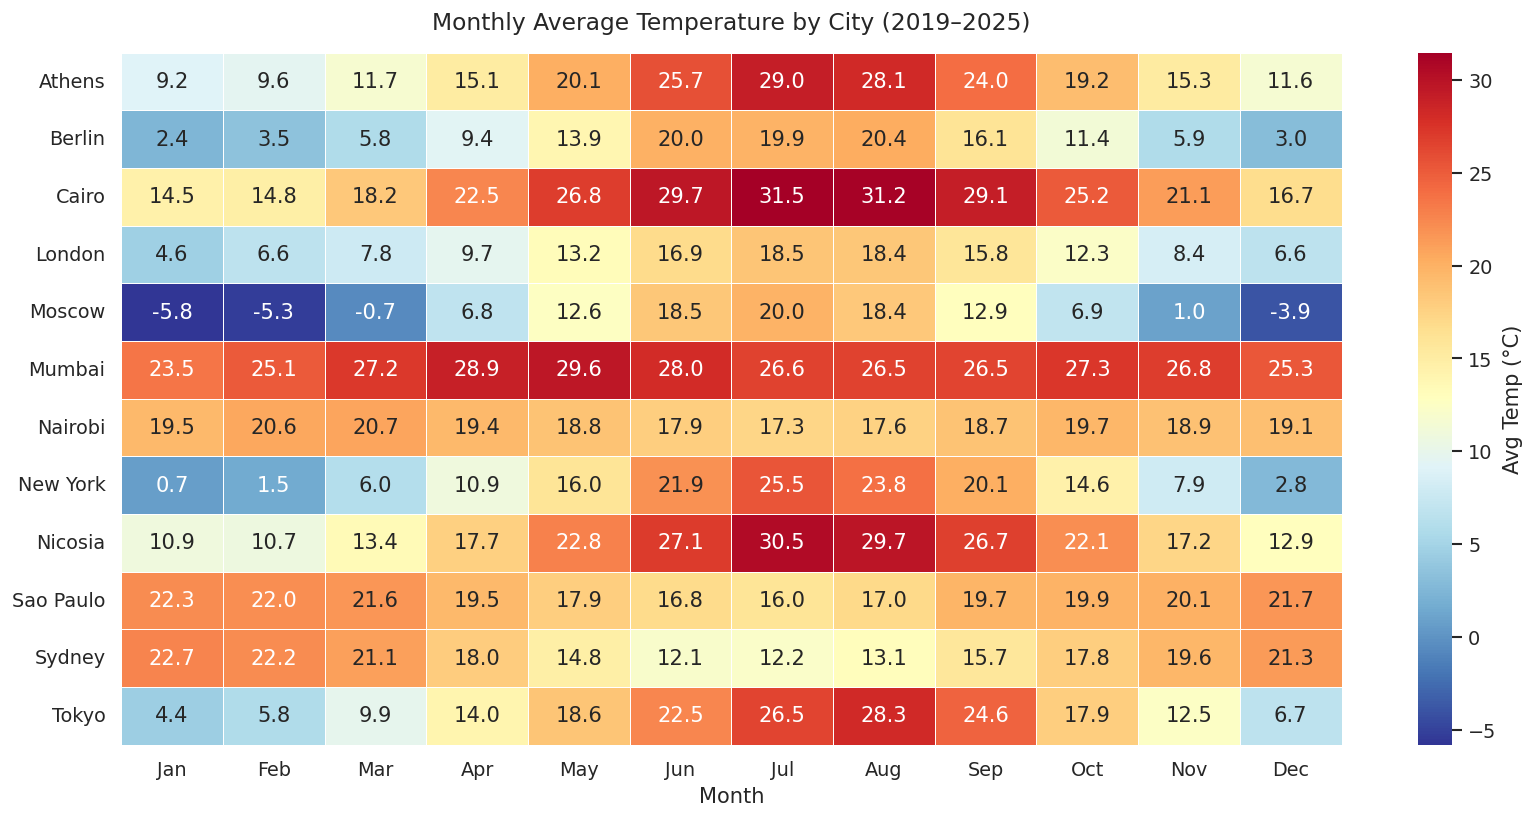

Plot saved: eda_monthly_temp_heatmap.png


In [ ]:
monthly_avg = sdf.groupBy("city", "year", "month") \
    .agg(F.round(F.mean("temperature_2m"), 2).alias("avg_temp")) \
    .orderBy("city", "year", "month") \
    .toPandas()

# Pivot for heatmap
pivot = monthly_avg.groupby(["city", "month"])["avg_temp"].mean().unstack()
pivot.index = [c.replace("_", " ") for c in pivot.index]
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlBu_r",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Avg Temp (°C)"})
ax.set_title("Monthly Average Temperature by City (2019–2025)", fontsize=14, pad=14)
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("eda_monthly_temp_heatmap.png", bbox_inches="tight")
plt.show()
print("Plot saved: eda_monthly_temp_heatmap.png")

## 1.5 Annual Temperature Trend (Year-over-Year)


In [ ]:
yearly = sdf.groupBy("city", "year") \
    .agg(F.round(F.mean("temperature_2m"), 3).alias("avg_temp")) \
    .orderBy("city", "year") \
    .toPandas()

# Compute first-to-last difference per city
diffs = yearly.groupby("city").agg(
    first_year=("year", "min"),
    last_year=("year", "max"),
    first_temp=("avg_temp", "first"),
    last_temp=("avg_temp", "last"),
).reset_index()
diffs["delta"] = (diffs["last_temp"] - diffs["first_temp"]).round(3)
diffs = diffs.sort_values("delta", ascending=False)

print("Temperature change (first → last year) per city:")
print(diffs[["city", "first_year", "last_year", "first_temp", "last_temp", "delta"]].to_string(index=False))


Temperature change (first → last year) per city:
     city  first_year  last_year  first_temp  last_temp  delta
    Tokyo        2019       2025      15.380     16.895  1.515
   London        2019       2025      11.089     12.414  1.325
   Athens        2019       2025      17.815     18.915  1.100
   Mumbai        2019       2025      26.307     27.317  1.010
    Cairo        2019       2025      23.038     24.032  0.994
   Moscow        2019       2025       7.172      8.145  0.973
  Nicosia        2019       2025      19.731     20.495  0.764
  Nairobi        2019       2025      19.024     19.532  0.508
 New_York        2019       2025      12.089     12.527  0.438
Sao_Paulo        2019       2025      19.701     20.075  0.374
   Sydney        2019       2025      17.889     18.134  0.245
   Berlin        2019       2025      11.451     10.653 -0.798


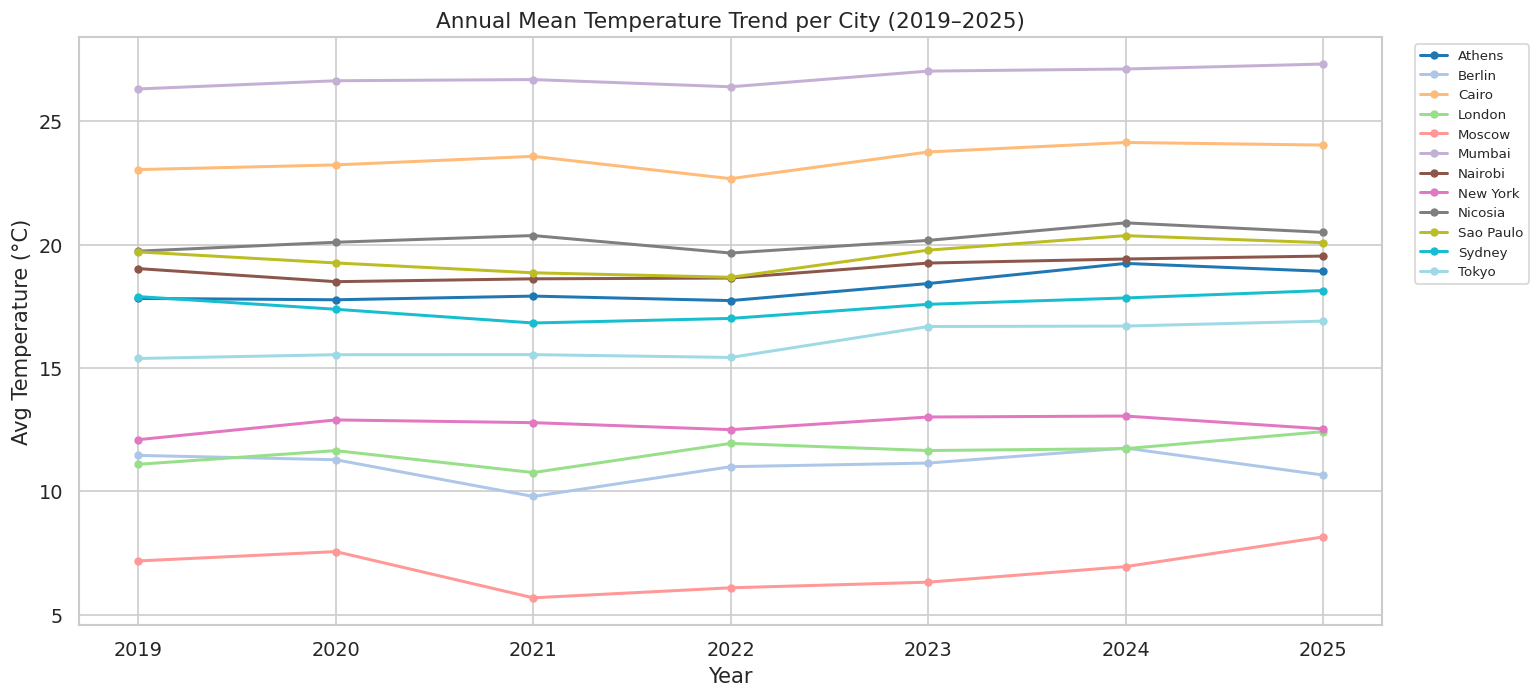

In [ ]:
yearly = sdf.groupBy("city", "year") \
    .agg(F.round(F.mean("temperature_2m"), 3).alias("avg_temp")) \
    .orderBy("city", "year") \
    .toPandas()

cities = yearly["city"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(cities)))
color_map = dict(zip(cities, colors))

fig, ax = plt.subplots(figsize=(13, 6))
for city, grp in yearly.groupby("city"):
    ax.plot(grp["year"], grp["avg_temp"], marker="o", linewidth=1.8,
            markersize=4, label=city.replace("_", " "), color=color_map[city])

ax.set_title("Annual Mean Temperature Trend per City (2019–2025)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Avg Temperature (°C)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("eda_yearly_temp_trend.png", bbox_inches="tight")
plt.show()

## 1.6 Diurnal (Daily) Temperature Cycle


Diurnal temperature range per city:
     city  temp_range
    Cairo       11.78
  Nicosia       11.11
  Nairobi       10.06
Sao_Paulo        8.57
    Tokyo        7.35
   Sydney        7.26
 New_York        7.19
   Athens        7.07
   Mumbai        6.30
   Berlin        6.30
   London        6.01
   Moscow        5.63


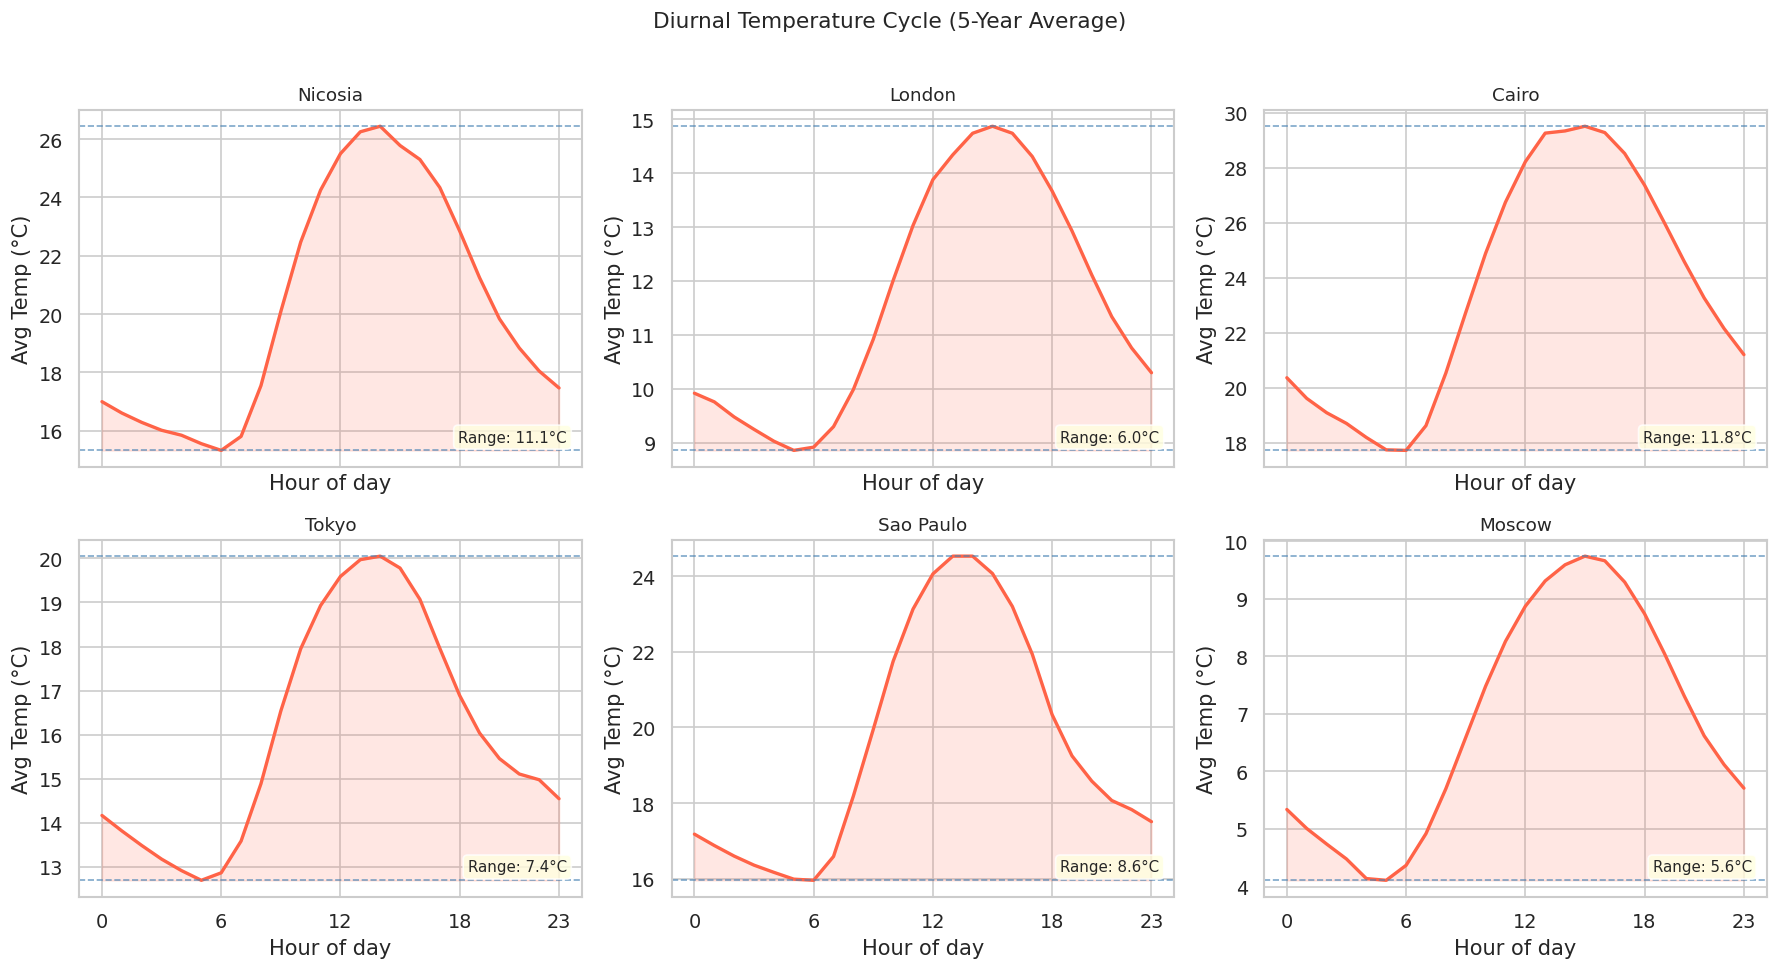

In [ ]:
diurnal = sdf.groupBy("city", "hour") \
    .agg(F.round(F.mean("temperature_2m"), 2).alias("avg_temp")) \
    .orderBy("city", "hour") \
    .toPandas()

selected_cities = ["Nicosia", "London", "Cairo", "Tokyo", "Sao_Paulo", "Moscow"]

# ── NEW: compute diurnal range per city ──────────────────────────────────────
diurnal_range = (
    diurnal.groupby("city")["avg_temp"]
    .agg(lambda s: s.max() - s.min())
    .rename("temp_range")
    .reset_index()
    .sort_values("temp_range", ascending=False)
)
print("Diurnal temperature range per city:")
print(diurnal_range.to_string(index=False))
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for ax, city in zip(axes, selected_cities):
    grp = diurnal[diurnal["city"] == city]
    temp_range = diurnal_range.loc[diurnal_range["city"] == city, "temp_range"].values[0]

    ax.plot(grp["hour"], grp["avg_temp"], color="tomato", linewidth=2)
    ax.fill_between(grp["hour"], grp["avg_temp"].min(), grp["avg_temp"],
                    alpha=0.15, color="tomato")

    # ── NEW: annotate each subplot with the range value ───────────────────
    ax.axhline(grp["avg_temp"].max(), color="steelblue", linewidth=1,
               linestyle="--", alpha=0.7)
    ax.axhline(grp["avg_temp"].min(), color="steelblue", linewidth=1,
               linestyle="--", alpha=0.7)
    ax.annotate(f"Range: {temp_range:.1f}°C",
                xy=(0.97, 0.07), xycoords="axes fraction",
                ha="right", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
    # ─────────────────────────────────────────────────────────────────────

    ax.set_title(city.replace("_", " "), fontsize=11)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Avg Temp (°C)")
    ax.set_xticks([0, 6, 12, 18, 23])

fig.suptitle("Diurnal Temperature Cycle (5-Year Average)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("eda_diurnal_cycle.png", bbox_inches="tight")
plt.show()

## Phase 1 — Exploratory Data Analysis (EDA)


### EDA SUMMARY

Total observations  : 736,416
Cities              : 12
Years               : 7
Variables analysed  : 8

Key findings:
  - Cairo and Mumbai show the highest mean temperatures
  - Moscow and Berlin show the widest seasonal temperature swings
  - Mumbai and Sao Paulo receive the most precipitation (monsoon/tropical)
  - Strong negative correlation between cloud cover and solar radiation
  - Temperature and apparent_temperature are highly correlated (r > 0.99)
  - Heatwave days are concentrated in Mediterranean and Desert climates


EDA is performed in Apache Spark 4.0 (4 GB driver, 8 shuffle partitions) directly on the 736,416-row DataFrame, using SQL aggregates, window functions, and Spark MLlib's `Correlation` API. Plots are produced with Matplotlib/Seaborn after aggregation collapses the data to summary size.

### Descriptive statistics

Global ranges confirm the data is physically plausible — temperatures span -31 °C (Moscow) to 45 °C (Cairo), pressure ranges from 833 to 1046 hPa, and wind gusts up to 92.7 km/h:

| Variable | Min | Mean | Max | Std |
|---|---|---|---|---|
| Temperature (°C) | -31.0 | 16.91 | 45.1 | 9.22 |
| Apparent temperature (°C) | -36.9 | 16.01 | 46.1 | 11.27 |
| Relative humidity (%) | 3 | 69.93 | 100 | 20.64 |
| Precipitation (mm/hr) | 0.0 | 0.11 | 47.6 | 0.59 |
| Wind speed (km/h) | 0.0 | 11.69 | 92.7 | 6.73 |
| Surface pressure (hPa) | 833.1 | 986.69 | 1045.8 | 49.71 |
| Cloud cover (%) | 0 | 52.73 | 100 | 42.50 |
| Shortwave radiation (W/m²) | 0.0 | 186.37 | 1116.0 | 268.82 |

Per-city aggregates rank cities from Mumbai (mean 26.8 °C) at the top to Moscow (6.8 °C) at the bottom — a 20 °C spread that reflects the geographic diversity of the sample.

### Key visualisations


**1. Monthly average temperature heatmap** — exposes three distinct seasonal regimes: Northern-Hemisphere cities (Moscow, Berlin, London, New York, Tokyo, the Mediterraneans, Cairo) peak in June-August; Southern-Hemisphere cities-(Sydney, São Paulo) mirror that pattern with peaks in December-February; equatorial cities (Mumbai, Nairobi) stay within ~-4 °C all year, showing year-round isothermality.

**2. Diurnal temperature cycle** — Cairo has the largest daily swing (11.8 °C) and Moscow the smallest (5.6 °C). The pattern is physical: dry, clear-sky climates allow rapid longwave cooling at night and strong solar heating by day, while humid or high-latitude cities damp the cycle through cloud cover and persistent moisture.

**3. Precipitation by city and season** — Mumbai dominates at 17,550 mm of total rainfall over the period, more than triple Athens (3,774 mm) and over 60× Cairo (280 mm). The seasonal heatmap shows the South-Asian monsoon concentrates virtually all of Mumbai's rainfall in summer, while London and Berlin distribute precipitation evenly across the year.
